# Content Modifications Over Time

Temporal analysis of audio/video content revisions, focusing on:
- yearly trends up to the end of 2025, and
- cyclical monthly patterns over the most recent ~60 months.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [6]:
# Load audio/video revision data for temporal analysis
base_path = Path('../etl-output')
audiovisual_path = base_path / 'contentservice' / 'audiovideoprocessed' / 'data'

print("Loading audio/video data for temporal modification analysis...")
av_files = glob.glob(str(audiovisual_path / 'part-*.csv'))

if not av_files:
    raise FileNotFoundError(f"No audio/video files found at {audiovisual_path}")

av_data = pd.concat([pd.read_csv(f) for f in av_files], ignore_index=True)
print(f"Loaded {len(av_data):,} audio/video revision records")
print("Columns:", av_data.columns.tolist())

Loading audio/video data for temporal modification analysis...
Loaded 35,831 audio/video revision records
Columns: ['content_id', 'revision_id', 'revision_number', 'type', 'source', 'revision_size', 'duration', 'required_transcoding', 'required_transcribing', 'last_modified']


Definition of 'modifications' in this analysis:
- Each row in av_data is a revision event for an audio/video item.
- We count all revision events with a valid last_modified timestamp as 'modifications'.
- Total revision events (counted as 'modifications'): 35,831
  * Initial revisions (creation events, revision_number == 1): 35,762
  * Subsequent revisions (updates, revision_number > 1): 69

Note: Delete operations are not visible in this dataset, so they are not counted here.

Content Modifications by Year (through 2025):


modification_year
2022     7033
2023     7133
2024     8120
2025    12008
Name: count, dtype: int64


Modifications after 2025 (not shown in the yearly plot above):


modification_year
2026    1537
Name: count, dtype: int64

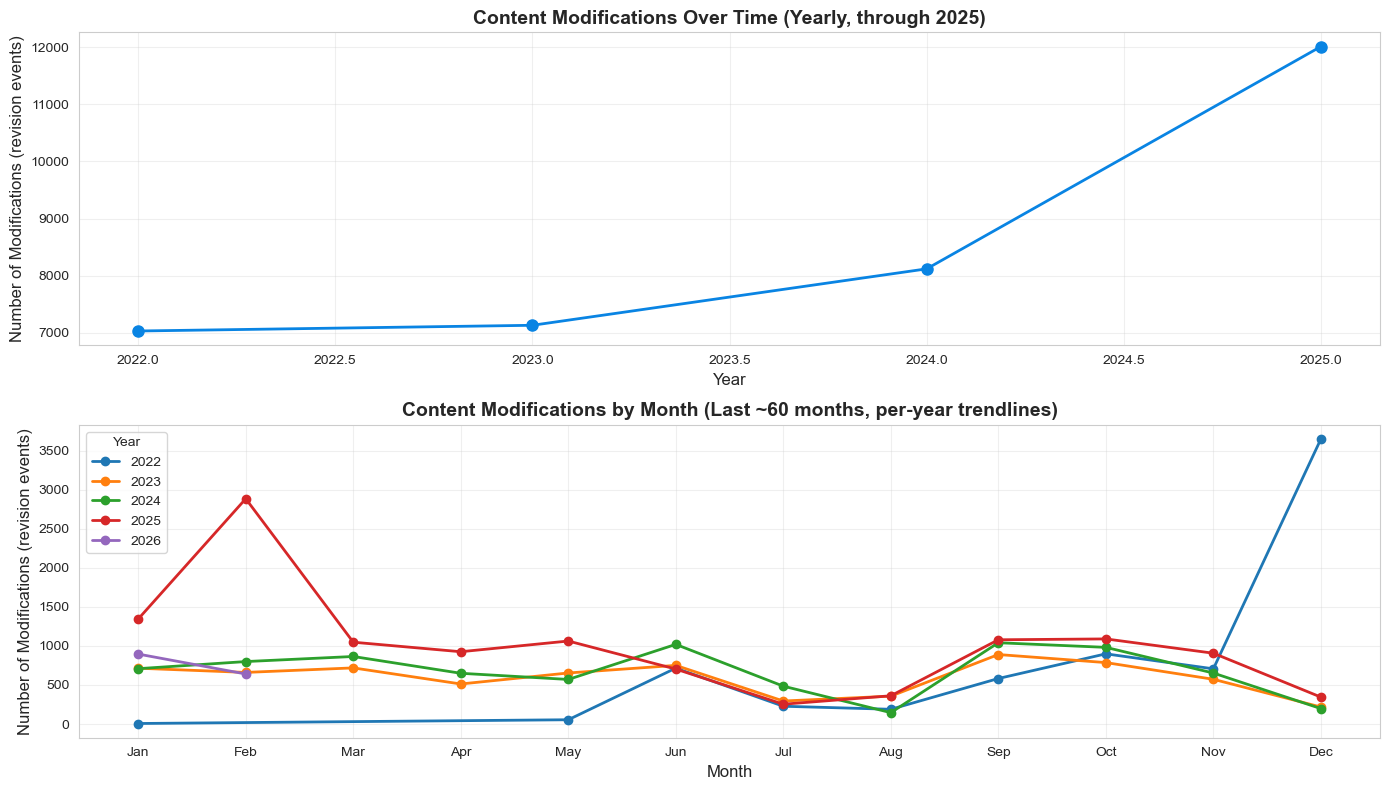

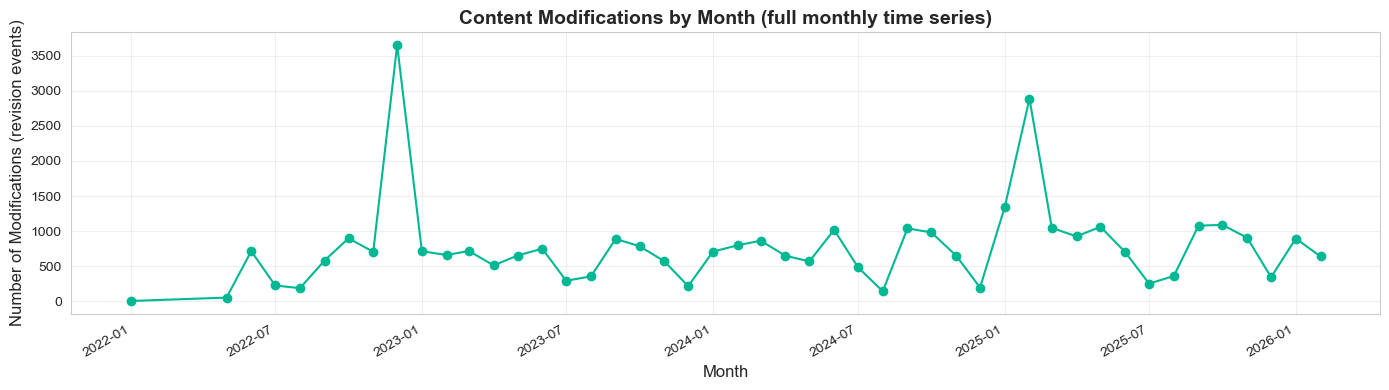

In [9]:
# Prepare temporal fields and analyze content modifications over time

# Step 1: Derive year and month components from the raw last_modified timestamp.
# These temporal features are the basis for all downstream aggregation.
if 'last_modified' in av_data.columns:
    # Coerce the last_modified field to datetime; invalid parses become NaT.
    av_data['last_modified'] = pd.to_datetime(av_data['last_modified'], errors='coerce')
    # Calendar year of each modification event.
    av_data['modification_year'] = av_data['last_modified'].dt.year
    # Month as a Period[M] so we can group and sort at month granularity.
    av_data['modification_month'] = av_data['last_modified'].dt.to_period('M')
else:
    # If timestamps are unavailable, the temporal analyses below will not be meaningful.
    av_data['modification_year'] = np.nan
    av_data['modification_month'] = pd.NaT

# Step 2: Define what we mean by a "modification" and expose simple counts
# to distinguish between initial creations and subsequent updates.
if 'modification_year' in av_data.columns and av_data['modification_year'].notna().any():
    print("Definition of 'modifications' in this analysis:")
    print("=" * 60)
    if 'revision_number' in av_data.columns:
        # Each row in av_data is a revision event; use revision_number to separate
        # initial creations (revision_number == 1) from follow-up updates (> 1).
        total_events = len(av_data)
        initial_events = (av_data['revision_number'] == 1).sum()
        subsequent_events = total_events - initial_events
        print("- Each row in av_data is a revision event for an audio/video item.")
        print("- We count all revision events with a valid last_modified timestamp as 'modifications'.")
        print(f"- Total revision events (counted as 'modifications'): {total_events:,}")
        print(f"  * Initial revisions (creation events, revision_number == 1): {initial_events:,}")
        print(f"  * Subsequent revisions (updates, revision_number > 1): {subsequent_events:,}")
    else:
        # Fallback: if revision_number is not present, treat every timestamped row
        # as a generic modification event without distinguishing create vs update.
        print("- Each row in av_data with a valid last_modified timestamp is treated as a 'modification' event.")
    print("\nNote: Delete operations are not visible in this dataset, so they are not counted here.\n")

    # Step 3: Aggregate modification events by calendar year, but explicitly cap
    # the visualization at the end of 2025 to align with the reporting horizon.
    year_counts_all = av_data['modification_year'].value_counts().sort_index()
    year_counts = year_counts_all[year_counts_all.index <= 2025]

    print("Content Modifications by Year (through 2025):")
    print("=" * 60)
    display(year_counts)

    # Surface activity that occurred after 2025 in tabular form, without plotting
    # it in the yearly trendline above.
    if (year_counts_all.index > 2025).any():
        future_years = year_counts_all[year_counts_all.index > 2025]
        print("\nModifications after 2025 (not shown in the yearly plot above):")
        display(future_years)

    # Step 4: Visualize yearly and monthly patterns.
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # 4a. Yearly trend (through 2025): shows the overall trajectory of
    # multimedia revision activity year-over-year.
    year_counts.plot(kind='line', ax=axes[0], marker='o', linewidth=2, markersize=8, color='#0984E3')
    axes[0].set_title('Content Modifications Over Time (Yearly, through 2025)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel('Number of Modifications (revision events)', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    # 4b. Monthly trend: emphasize seasonality by plotting separate disjoint
    # trendlines for each year over the last ~60 months.
    if 'modification_month' in av_data.columns and av_data['modification_month'].notna().any():
        # Full monthly counts over the entire history, then restrict to the most
        # recent ~5 years for the per-year seasonal view.
        monthly_counts = av_data['modification_month'].value_counts().sort_index()
        recent_monthly = monthly_counts.tail(60)  # Last ~60 months

        # Convert to a tidy DataFrame with explicit year and month components.
        monthly_df = recent_monthly.reset_index()
        monthly_df.columns = ['modification_month', 'count']
        monthly_df['year'] = monthly_df['modification_month'].dt.year
        monthly_df['month'] = monthly_df['modification_month'].dt.month

        # Draw one line per year on a common 1–12 month axis to make any
        # recurring seasonal patterns easier to spot.
        for year, group in monthly_df.groupby('year'):
            axes[1].plot(group['month'], group['count'], marker='o', linewidth=2, markersize=6, label=str(year))

        axes[1].set_title('Content Modifications by Month (Last ~60 months, per-year trendlines)', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Month', fontsize=12)
        axes[1].set_ylabel('Number of Modifications (revision events)', fontsize=12)
        axes[1].set_xticks(range(1, 13))
        axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
        axes[1].legend(title='Year')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Step 5: Complement the per-year seasonal view with a single continuous
        # monthly time series across the full history. This helps highlight
        # long-term growth/decline patterns that may be less obvious when
        # months are overlaid by year.
        fig2, ax2 = plt.subplots(1, 1, figsize=(14, 4))
        full_monthly_df = monthly_counts.reset_index()
        full_monthly_df.columns = ['modification_month', 'count']
        # Convert Period[M] to a concrete timestamp at the start of each month
        # so we can place points correctly on a date-based x-axis.
        full_monthly_df['month_start'] = full_monthly_df['modification_month'].dt.to_timestamp()

        ax2.plot(full_monthly_df['month_start'], full_monthly_df['count'],
                 marker='o', linewidth=1.5, color='#00B894')
        ax2.set_title('Content Modifications by Month (full monthly time series)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Month', fontsize=12)
        ax2.set_ylabel('Number of Modifications (revision events)', fontsize=12)
        ax2.grid(True, alpha=0.3)
        fig2.autofmt_xdate()
        plt.tight_layout()
        plt.show()
else:
    # If we cannot derive a valid modification_year, surface that explicitly so
    # the reader understands why no plots or tables are produced.
    print("Temporal data not available or contains insufficient valid dates.")